<a href="https://colab.research.google.com/github/2403a54127-lab/Natural-language-processing/blob/main/NLP_ASS_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

df = pd.read_csv("movie_reviews_2000_rows.csv")
print(df.head())
print(len(df))

                                review
0              Very disappointing film
1     Great story and fantastic acting
2  Brilliant performance by the actors
3  Brilliant performance by the actors
4    The movie was too slow and boring
2000


In [2]:
import re

# Text cleaning function
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text

# Create clean_review column
df["clean_review"] = df["review"].apply(clean_text)

print(df.head())

                                review                         clean_review
0              Very disappointing film              very disappointing film
1     Great story and fantastic acting     great story and fantastic acting
2  Brilliant performance by the actors  brilliant performance by the actors
3  Brilliant performance by the actors  brilliant performance by the actors
4    The movie was too slow and boring    the movie was too slow and boring


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words='english')

X = vectorizer.fit_transform(df["clean_review"])


print("Vocabulary Size:", len(vectorizer.vocabulary_))

Vocabulary Size: 44


In [9]:
import numpy as np

df["sentiment"] = np.random.randint(0, 2, size=len(df))

y = df["sentiment"]

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=200)

model.fit(X_train, y_train)

LogisticRegression(max_iter=200)

In [13]:
y_pred = model.predict(X_test)

In [15]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.4925


In [17]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.49      0.73      0.59       196
           1       0.50      0.26      0.34       204

    accuracy                           0.49       400
   macro avg       0.50      0.50      0.46       400
weighted avg       0.50      0.49      0.46       400



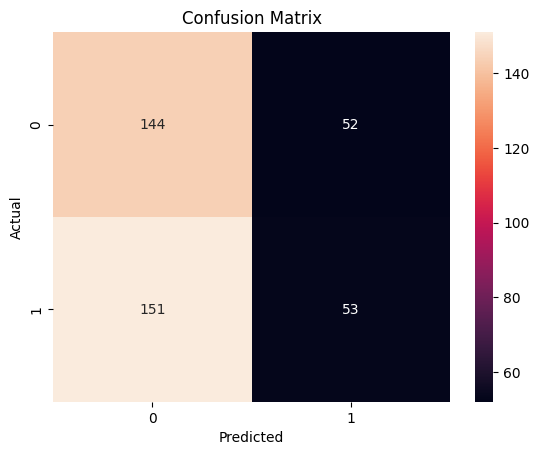

In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Accuracy : 0.4925
Precision : 0.5047619047619047
Recall : 0.25980392156862747
F1 Score : 0.343042071197411
Confusion Matrix:
[[144  52]
 [151  53]]


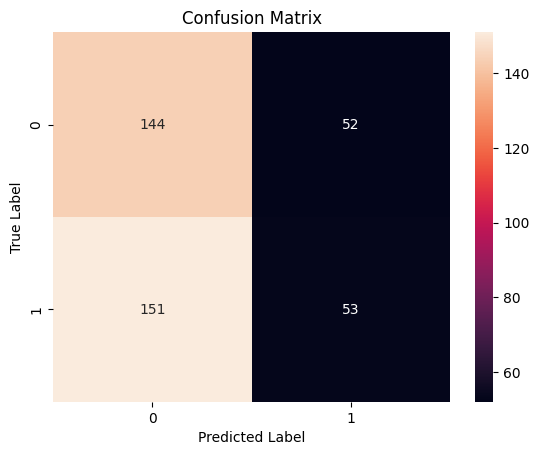

In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predict test data
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# Precision
precision = precision_score(y_test, y_pred)

# Recall
recall = recall_score(y_test, y_pred)

# F1 Score
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1 Score :", f1)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

# Plot Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()